# Feature Importance Analysis

Three approaches to assess feature–target relationships:
1. **Grey Relational Analysis (GRA-GRG)** — non-linear, non-parametric ranking
2. **Pearson & Spearman correlations** — linear vs. monotonic association
3. **Tree-based importance** — XGBoost gain-based importance

Targets: `y_alpha` (regression), `barrier_label` (ternary classification), `regime_label` (ternary classification)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")

# --- Load feature datasets ---
alpha_feat = pd.read_csv(PROCESSED / "alpha_features.csv", parse_dates=["date"])
gate_feat  = pd.read_csv(PROCESSED / "gate_features.csv",  parse_dates=["date"])
regime_feat = pd.read_csv(PROCESSED / "regime_features.csv", parse_dates=["date"])

# --- Load backbone (has OHLC + adj_close alongside all features) ---
backbone = pd.read_csv(PROCESSED / "backbone.csv", parse_dates=["date"])
ohlc_cols = ["open", "high", "low", "close", "adj_close"]
ohlc_slice = backbone[["date", "symbol"] + ohlc_cols]

# Merge OHLC into alpha and gate feature sets
alpha_feat = alpha_feat.merge(ohlc_slice, on=["date", "symbol"], how="left")
gate_feat  = gate_feat.merge(ohlc_slice, on=["date", "symbol"], how="left")

# --- Load targets ---
alpha_tgt  = pd.read_csv(PROCESSED / "alpha_targets.csv",  parse_dates=["date"])
barrier_tgt = pd.read_csv(PROCESSED / "barrier_labels.csv", parse_dates=["date"])
regime_tgt  = pd.read_csv(PROCESSED / "regime_labels.csv",  parse_dates=["date"])

# --- Convert alpha target: log return → simple percentage return ---
# y_alpha is log(AdjClose_{t+10}/AdjClose_t), convert to (AdjClose_{t+10}/AdjClose_t) - 1
alpha_tgt["y_alpha"] = np.exp(alpha_tgt["y_alpha"]) - 1.0

print(f"Alpha features (+ OHLC): {alpha_feat.shape}")
print(f"Gate features  (+ OHLC): {gate_feat.shape}")
print(f"Regime features:         {regime_feat.shape}")
print(f"Alpha targets:           {alpha_tgt.shape}")
print(f"Barrier labels:          {barrier_tgt.shape}")
print(f"Regime labels:           {regime_tgt.shape}")
print(f"\nOHLC columns added: {ohlc_cols}")
print(f"Alpha target (simple return): mean={alpha_tgt['y_alpha'].mean():.6f}, std={alpha_tgt['y_alpha'].std():.6f}")

Alpha features (+ OHLC): (22959, 45)
Gate features  (+ OHLC): (22959, 50)
Regime features:         (2640, 10)
Alpha targets:           (22829, 3)
Barrier labels:          (22582, 3)
Regime labels:           (2640, 2)

OHLC columns added: ['open', 'high', 'low', 'close', 'adj_close']
Alpha target (simple return): mean=0.003779, std=0.055762


In [2]:
# --- Merge features with targets ---
# Alpha: ETF-level features (+ OHLC) → y_alpha
alpha_df = alpha_feat.merge(alpha_tgt, on=["date", "symbol"], how="inner")
alpha_xcols = [c for c in alpha_feat.columns if c not in ("date", "symbol")]

# Gate: ETF-level features (+ OHLC) → barrier_label
gate_df = gate_feat.merge(barrier_tgt, on=["date", "symbol"], how="inner")
gate_xcols = [c for c in gate_feat.columns if c not in ("date", "symbol")]

# Regime: date-level features → regime_label (no OHLC — these are market-wide)
regime_df = regime_feat.merge(regime_tgt, on="date", how="inner")
regime_xcols = [c for c in regime_feat.columns if c != "date"]

print(f"Alpha merged:  {alpha_df.shape}  features: {len(alpha_xcols)} (incl OHLC)")
print(f"Gate merged:   {gate_df.shape}  features: {len(gate_xcols)} (incl OHLC)")
print(f"Regime merged: {regime_df.shape}  features: {len(regime_xcols)}")

# Drop rows with any NaN in features for clean analysis
alpha_clean = alpha_df.dropna(subset=alpha_xcols + ["y_alpha"])
gate_clean  = gate_df.dropna(subset=gate_xcols + ["barrier_label"])
regime_clean = regime_df.dropna(subset=regime_xcols + ["regime_label"])

print(f"\nAfter dropna:")
print(f"Alpha:  {len(alpha_clean)} rows  ({len(alpha_xcols)} features)")
print(f"Gate:   {len(gate_clean)} rows  ({len(gate_xcols)} features)")
print(f"Regime: {len(regime_clean)} rows  ({len(regime_xcols)} features)")
print(f"\nAlpha feature list: {sorted(alpha_xcols)}")

Alpha merged:  (22829, 46)  features: 43 (incl OHLC)
Gate merged:   (22582, 51)  features: 48 (incl OHLC)
Regime merged: (2640, 11)  features: 9

After dropna:
Alpha:  22829 rows  (43 features)
Gate:   22582 rows  (48 features)
Regime: 2620 rows  (9 features)

Alpha feature list: ['abs_ret1_adj', 'adj_close', 'adj_over_ma10', 'adj_over_ma20', 'atr14_over_adj', 'close', 'dxy_ret_lag1', 'ema10_over_ema20_adj', 'gap_open_prev_adj', 'high', 'hl_range_adjproxy', 'ieur_ret10d_lag1', 'ieur_ret_lag1', 'log_volume', 'low', 'ma10_over_ma20_adj', 'open', 'qqq_ret_lag1', 'rank_volume_cross', 'rel10_ieur', 'rel10_spy', 'ret10_adj', 'ret10_over_rv10', 'ret1_adj', 'ret20_adj', 'ret20_over_rv20', 'ret3_adj', 'ret5_adj', 'rv10_adj', 'rv20_adj', 'rv5_adj', 'slope10_adj', 'slope5_adj', 'spy_ret10d_lag1', 'spy_ret_lag1', 'us10y_chg_lag1', 'vix_chg_lag1', 'vol_ma_ratio20', 'vol_z20', 'zscore10_adj', 'zscore20_adj', 'zscore5_adj', 'zscore_ret10d_cross']


## 1. Grey Relational Analysis (GRA-GRG)

GRA measures similarity between each feature sequence and the target sequence after min-max normalisation. The Grey Relational Grade (GRG) ranges 0–1; higher = more similar dynamics to the target. Works well for non-linear, non-parametric importance ranking.

In [3]:
def grey_relational_grade(X: np.ndarray, y: np.ndarray, rho: float = 0.5) -> np.ndarray:
    """Compute GRG for each feature column in X against target y.
    
    Parameters
    ----------
    X : (n_samples, n_features) — feature matrix
    y : (n_samples,) — target vector
    rho : distinguishing coefficient (typically 0.5)
    
    Returns
    -------
    grg : (n_features,) — Grey Relational Grade per feature
    """
    # Min-max normalise each column independently
    def _minmax(arr):
        mn, mx = arr.min(), arr.max()
        if mx - mn < 1e-12:
            return np.zeros_like(arr)
        return (arr - mn) / (mx - mn)
    
    y_norm = _minmax(y)
    X_norm = np.column_stack([_minmax(X[:, j]) for j in range(X.shape[1])])
    
    # Absolute difference matrix |y - x_j| for each feature j
    delta = np.abs(X_norm - y_norm[:, None])  # (n, p)
    
    delta_min = delta.min()
    delta_max = delta.max()
    
    # Grey relational coefficient
    grc = (delta_min + rho * delta_max) / (delta + rho * delta_max + 1e-12)  # (n, p)
    
    # Grade = mean over samples
    grg = grc.mean(axis=0)  # (p,)
    return grg

In [4]:
# --- GRA for Alpha target ---
X_alpha = alpha_clean[alpha_xcols].values
y_alpha = alpha_clean["y_alpha"].values
grg_alpha = grey_relational_grade(X_alpha, y_alpha)
gra_alpha = pd.Series(grg_alpha, index=alpha_xcols, name="GRG").sort_values(ascending=False)

# --- GRA for Gate target (treat barrier_label as numeric) ---
X_gate = gate_clean[gate_xcols].values
y_gate = gate_clean["barrier_label"].values.astype(float)
grg_gate = grey_relational_grade(X_gate, y_gate)
gra_gate = pd.Series(grg_gate, index=gate_xcols, name="GRG").sort_values(ascending=False)

# --- GRA for Regime target ---
X_regime = regime_clean[regime_xcols].values
y_regime = regime_clean["regime_label"].values.astype(float)
grg_regime = grey_relational_grade(X_regime, y_regime)
gra_regime = pd.Series(grg_regime, index=regime_xcols, name="GRG").sort_values(ascending=False)

print("=== GRA-GRG: Alpha (top 15) ===")
print(gra_alpha.head(15).to_string())
print(f"\n=== GRA-GRG: Gate (top 15) ===")
print(gra_gate.head(15).to_string())
print(f"\n=== GRA-GRG: Regime (all {len(gra_regime)}) ===")
print(gra_regime.to_string())

=== GRA-GRG: Alpha (top 15) ===
adj_over_ma20        0.919717
adj_over_ma10        0.897346
ret10_over_rv10      0.810426
vix_chg_lag1         0.807256
gap_open_prev_adj    0.796357
vol_z20              0.790518
high                 0.780077
open                 0.779857
close                0.779794
low                  0.779597
slope10_adj          0.779507
adj_close            0.770862
ret20_over_rv20      0.748732
zscore20_adj         0.738426
ret1_adj             0.731030

=== GRA-GRG: Gate (top 15) ===
abs_ret1_adj           0.643551
rv5_adj                0.635792
downside_semivol_10    0.629824
rv10_adj               0.626809
cost_buffer_10         0.621743
max_drawdown_10        0.619058
rv20_adj               0.618511
gap_freq_10            0.615474
atr14_over_adj         0.607573
hl_range_adjproxy      0.596996
vol_ma_ratio20         0.596704
adj_close              0.565217
high                   0.563616
open                   0.563429
close                  0.563186

=== G

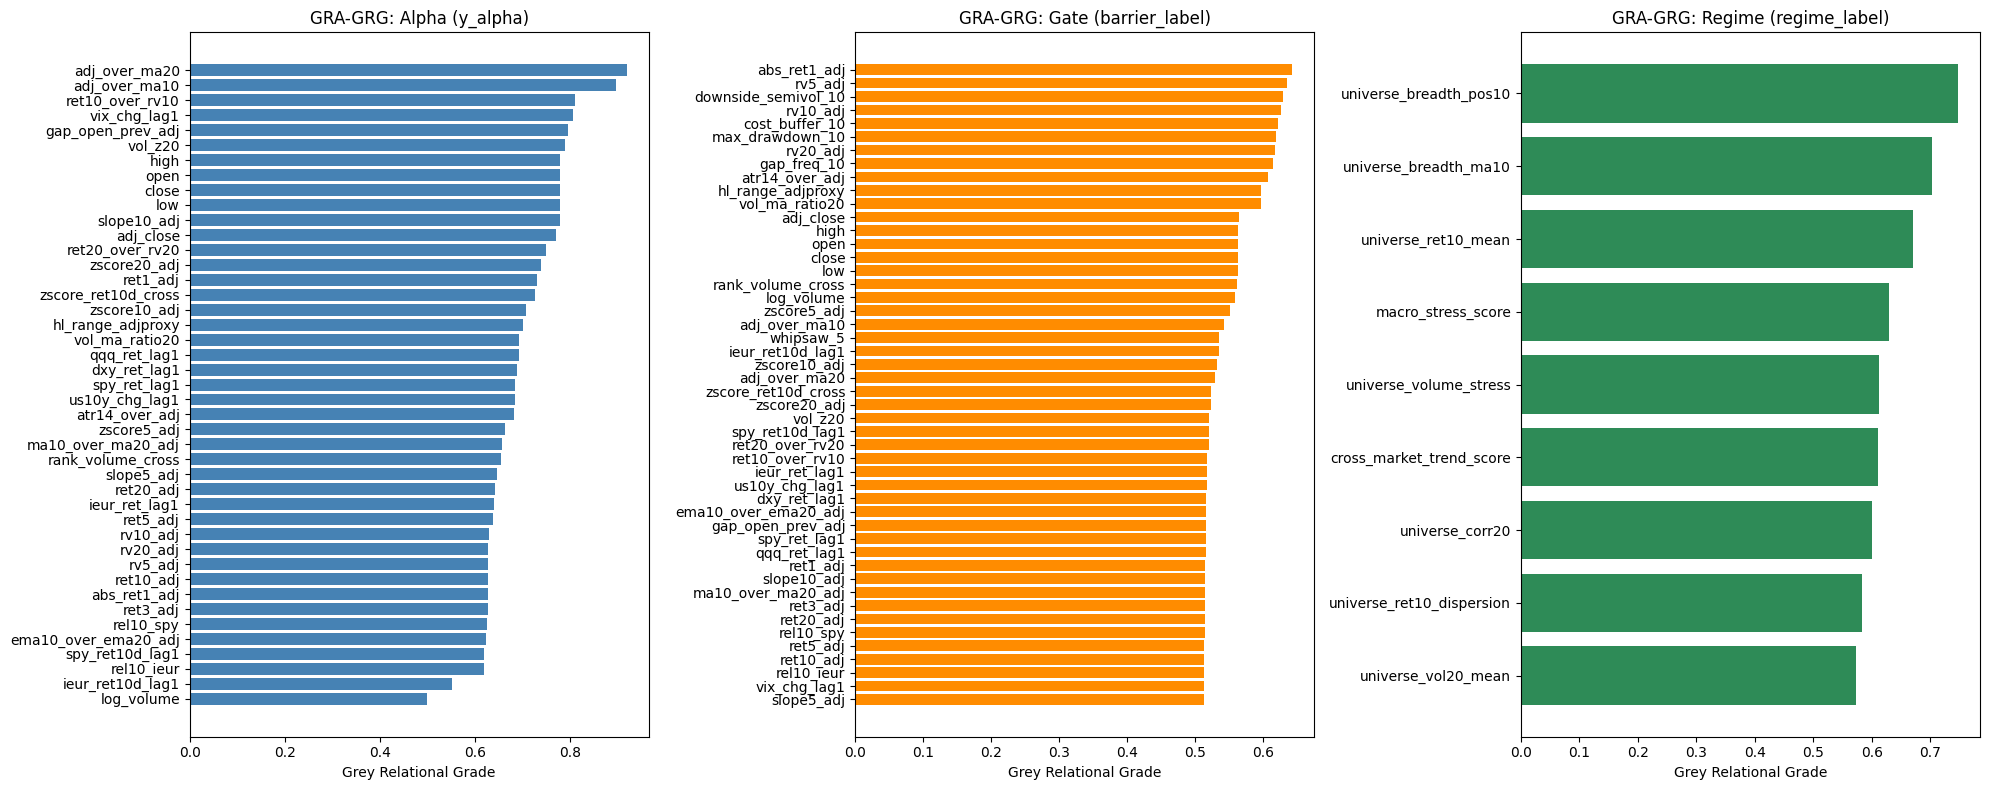

In [5]:
# --- GRA heatmap visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].barh(gra_alpha.index[::-1], gra_alpha.values[::-1], color="steelblue")
axes[0].set_title("GRA-GRG: Alpha (y_alpha)")
axes[0].set_xlabel("Grey Relational Grade")

axes[1].barh(gra_gate.index[::-1], gra_gate.values[::-1], color="darkorange")
axes[1].set_title("GRA-GRG: Gate (barrier_label)")
axes[1].set_xlabel("Grey Relational Grade")

axes[2].barh(gra_regime.index[::-1], gra_regime.values[::-1], color="seagreen")
axes[2].set_title("GRA-GRG: Regime (regime_label)")
axes[2].set_xlabel("Grey Relational Grade")

plt.tight_layout()
plt.show()

## 2. Pearson & Spearman Correlations

- **Pearson**: measures linear association — good for features with a direct linear relationship to the target
- **Spearman**: measures monotonic (rank) association — captures non-linear monotonic relationships

For classification targets (gate, regime) we treat the label as ordinal numeric.

In [6]:
from scipy.stats import spearmanr

def corr_table(df, feature_cols, target_col):
    """Compute Pearson and Spearman correlations for each feature vs target."""
    records = []
    y = df[target_col].values
    for col in feature_cols:
        x = df[col].values
        pearson = np.corrcoef(x, y)[0, 1]
        spearman, sp_pval = spearmanr(x, y)
        records.append({
            "feature": col,
            "pearson": pearson,
            "abs_pearson": abs(pearson),
            "spearman": spearman,
            "abs_spearman": abs(spearman),
            "spearman_pval": sp_pval,
        })
    return pd.DataFrame(records).sort_values("abs_spearman", ascending=False).reset_index(drop=True)

# Alpha
corr_alpha = corr_table(alpha_clean, alpha_xcols, "y_alpha")
print("=== Pearson & Spearman: Alpha (top 15 by |Spearman|) ===")
print(corr_alpha[["feature", "pearson", "spearman", "spearman_pval"]].head(15).to_string(index=False))

# Gate
corr_gate = corr_table(gate_clean, gate_xcols, "barrier_label")
print(f"\n=== Pearson & Spearman: Gate (top 15 by |Spearman|) ===")
print(corr_gate[["feature", "pearson", "spearman", "spearman_pval"]].head(15).to_string(index=False))

# Regime
corr_regime = corr_table(regime_clean, regime_xcols, "regime_label")
print(f"\n=== Pearson & Spearman: Regime (all {len(corr_regime)}) ===")
print(corr_regime[["feature", "pearson", "spearman", "spearman_pval"]].to_string(index=False))

=== Pearson & Spearman: Alpha (top 15 by |Spearman|) ===
           feature   pearson  spearman  spearman_pval
        log_volume -0.002839 -0.057946   1.916559e-18
    atr14_over_adj  0.018341  0.044606   1.554753e-11
     ieur_ret_lag1  0.026777  0.038188   7.847665e-09
      zscore20_adj  0.028463  0.036171   4.584459e-08
 gap_open_prev_adj  0.012311  0.035925   5.653819e-08
ma10_over_ma20_adj  0.022423  0.035113   1.116493e-07
   ret10_over_rv10  0.023932  0.035074   1.153458e-07
   ret20_over_rv20  0.028564  0.035007   1.219190e-07
     adj_over_ma20  0.008576  0.034738   1.521732e-07
         ret20_adj  0.012363  0.034407   1.993546e-07
    us10y_chg_lag1 -0.014421 -0.032751   7.442346e-07
           vol_z20  0.038115  0.030038   5.644769e-06
 hl_range_adjproxy  0.030838  0.029681   7.279621e-06
  ieur_ret10d_lag1  0.022947  0.029398   8.889308e-06
    vol_ma_ratio20  0.031243  0.024978   1.604503e-04

=== Pearson & Spearman: Gate (top 15 by |Spearman|) ===
          feature   pe

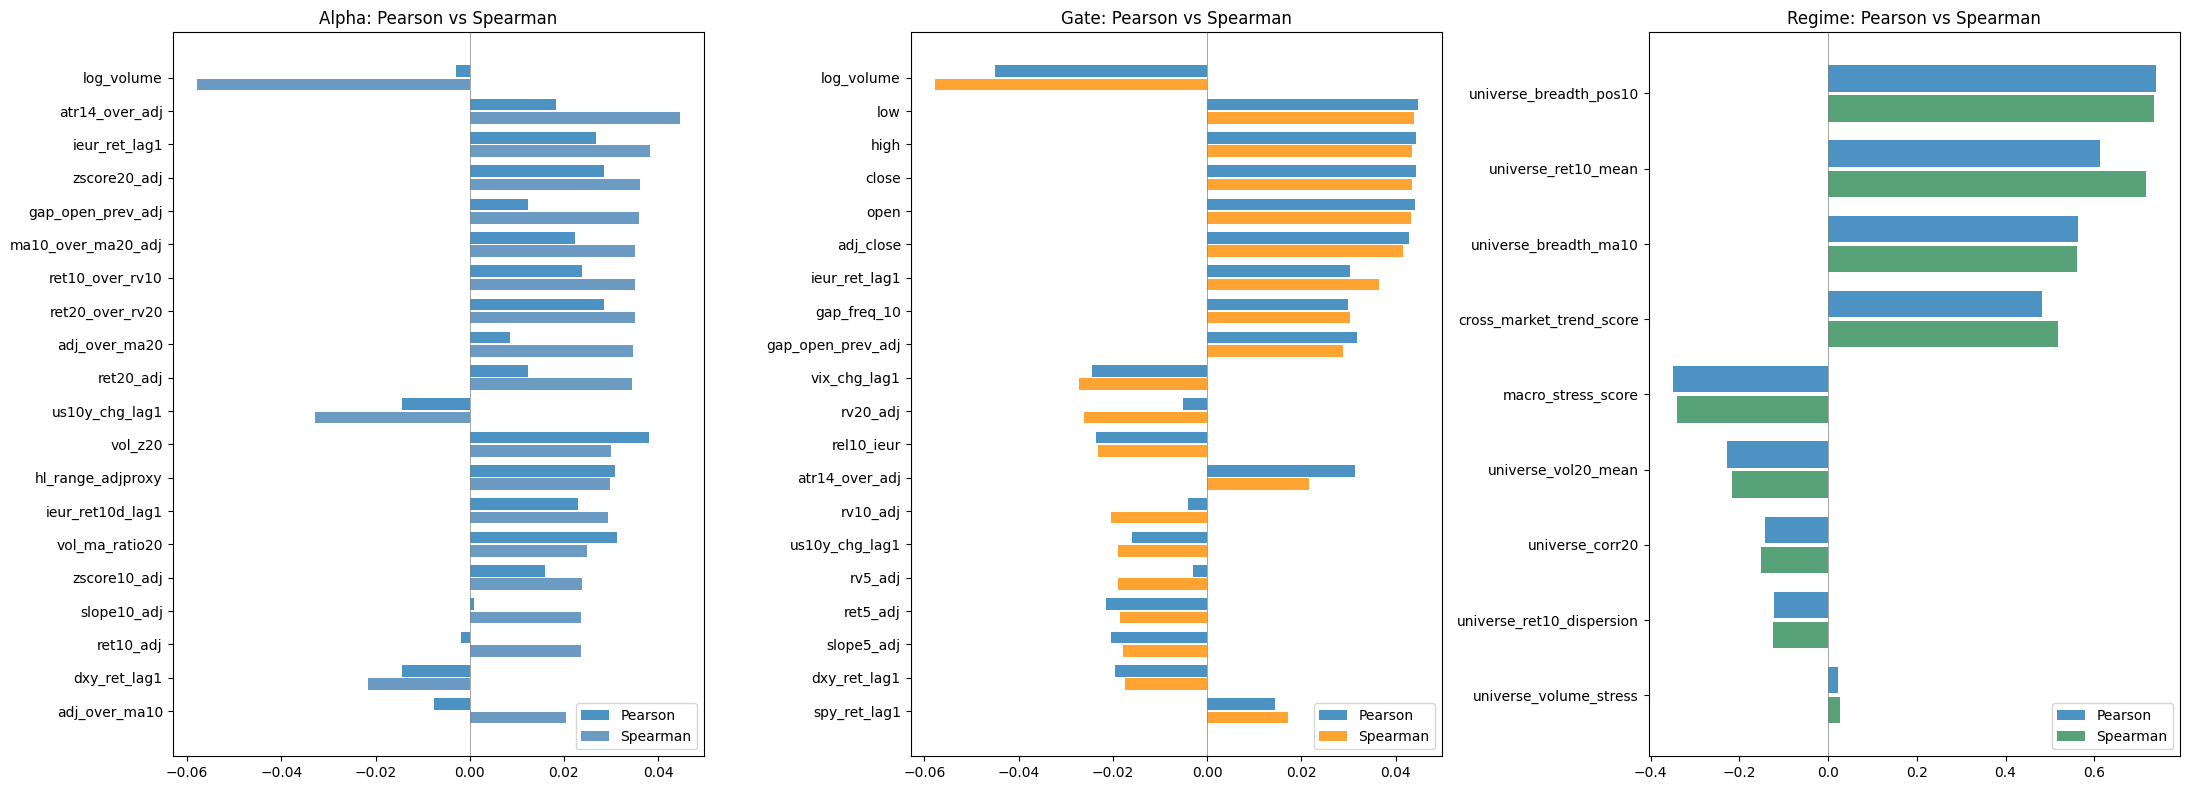

In [7]:
# --- Correlation heatmaps ---
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, corr_df, title, color in [
    (axes[0], corr_alpha, "Alpha: Pearson vs Spearman", "steelblue"),
    (axes[1], corr_gate,  "Gate: Pearson vs Spearman", "darkorange"),
    (axes[2], corr_regime, "Regime: Pearson vs Spearman", "seagreen"),
]:
    top = corr_df.head(min(20, len(corr_df)))
    y_pos = np.arange(len(top))
    ax.barh(y_pos - 0.2, top["pearson"].values, height=0.35, label="Pearson", alpha=0.8)
    ax.barh(y_pos + 0.2, top["spearman"].values, height=0.35, label="Spearman", alpha=0.8, color=color)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top["feature"].values)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.axvline(0, color="grey", linewidth=0.5)

plt.tight_layout()
plt.show()

## 3. Tree-Based Feature Importance (XGBoost)

XGBoost `gain`-based importance measures the average improvement in the loss function contributed by each feature across all splits. This captures non-linear, interaction-aware importance that correlation and GRA may miss.

- Alpha → XGBRegressor (squared error)
- Gate → XGBClassifier (multi:softprob, 3 classes)
- Regime → XGBClassifier (multi:softprob, 3 classes)

In [8]:
from xgboost import XGBRegressor, XGBClassifier

# Shared XGBoost params — lightweight, just enough to get stable importance
_XGB_COMMON = dict(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    importance_type="gain",
)

# --- Alpha regressor ---
xgb_alpha = XGBRegressor(**_XGB_COMMON)
xgb_alpha.fit(alpha_clean[alpha_xcols], alpha_clean["y_alpha"])
imp_alpha = pd.Series(
    xgb_alpha.feature_importances_, index=alpha_xcols, name="xgb_gain"
).sort_values(ascending=False)

# --- Gate classifier ---
# Remap barrier_label {-1, 0, 1} → {0, 1, 2} for XGBoost
gate_y_mapped = gate_clean["barrier_label"].map({-1: 0, 0: 1, 1: 2}).values
xgb_gate = XGBClassifier(
    **_XGB_COMMON,
    objective="multi:softprob",
    num_class=3,
)
xgb_gate.fit(gate_clean[gate_xcols], gate_y_mapped)
imp_gate = pd.Series(
    xgb_gate.feature_importances_, index=gate_xcols, name="xgb_gain"
).sort_values(ascending=False)

# --- Regime classifier ---
xgb_regime = XGBClassifier(
    **_XGB_COMMON,
    objective="multi:softprob",
    num_class=3,
)
xgb_regime.fit(regime_clean[regime_xcols], regime_clean["regime_label"].values)
imp_regime = pd.Series(
    xgb_regime.feature_importances_, index=regime_xcols, name="xgb_gain"
).sort_values(ascending=False)

print("=== XGBoost Gain Importance: Alpha (top 15) ===")
print(imp_alpha.head(15).to_string())
print(f"\n=== XGBoost Gain Importance: Gate (top 15) ===")
print(imp_gate.head(15).to_string())
print(f"\n=== XGBoost Gain Importance: Regime (all {len(imp_regime)}) ===")
print(imp_regime.to_string())

=== XGBoost Gain Importance: Alpha (top 15) ===
adj_close               0.033964
spy_ret_lag1            0.033307
ieur_ret10d_lag1        0.032366
qqq_ret_lag1            0.031139
spy_ret10d_lag1         0.029186
rv20_adj                0.029080
close                   0.028403
ret20_adj               0.028366
low                     0.028361
ieur_ret_lag1           0.027396
us10y_chg_lag1          0.026829
ret20_over_rv20         0.026679
high                    0.026368
ema10_over_ema20_adj    0.026164
rv10_adj                0.025757

=== XGBoost Gain Importance: Gate (top 15) ===
rv20_adj               0.042517
downside_semivol_10    0.027793
adj_close              0.027683
spy_ret10d_lag1        0.025813
low                    0.025199
close                  0.024135
ieur_ret10d_lag1       0.023759
high                   0.023294
atr14_over_adj         0.023137
spy_ret_lag1           0.023134
ieur_ret_lag1          0.022975
adj_over_ma20          0.022916
log_volume             0.

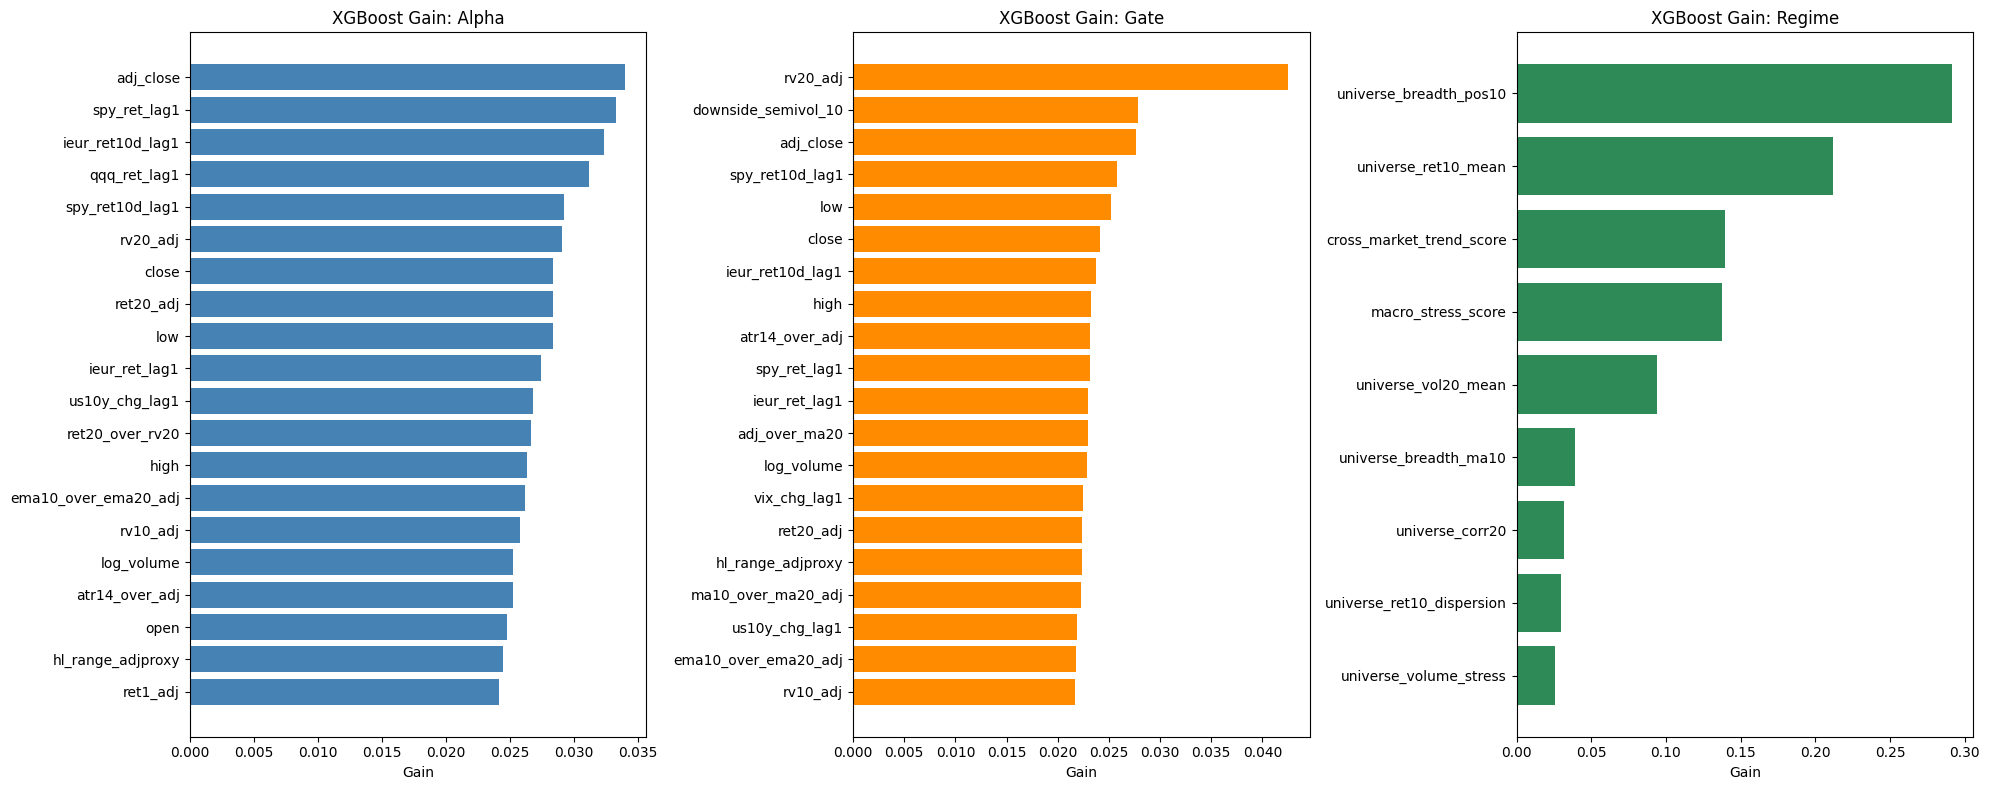

In [9]:
# --- XGBoost importance bar charts ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, imp, title, color in [
    (axes[0], imp_alpha, "XGBoost Gain: Alpha", "steelblue"),
    (axes[1], imp_gate,  "XGBoost Gain: Gate", "darkorange"),
    (axes[2], imp_regime, "XGBoost Gain: Regime", "seagreen"),
]:
    top = imp.head(min(20, len(imp)))
    ax.barh(top.index[::-1], top.values[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Gain")

plt.tight_layout()
plt.show()

## 3b. Random Forest Feature Importance (Alpha only)

RandomForest `impurity`-based importance (mean decrease in MSE) as a second tree-based lens on the alpha target. Compared to XGBoost, RF uses bagging (not boosting) and averages many independent trees — this gives a different bias on which features matter.

=== Random Forest Impurity Importance: Alpha (top 20) ===
ret20_adj               0.057752
ema10_over_ema20_adj    0.056092
rv20_adj                0.044038
low                     0.037827
open                    0.036494
adj_over_ma20           0.036141
high                    0.035773
ret20_over_rv20         0.035105
adj_close               0.034299
spy_ret10d_lag1         0.034244
rv10_adj                0.034200
close                   0.032856
ieur_ret10d_lag1        0.032772
ma10_over_ma20_adj      0.032127
log_volume              0.031802
adj_over_ma10           0.025154
atr14_over_adj          0.025114
hl_range_adjproxy       0.024620
rel10_spy               0.021983
rel10_ieur              0.021131


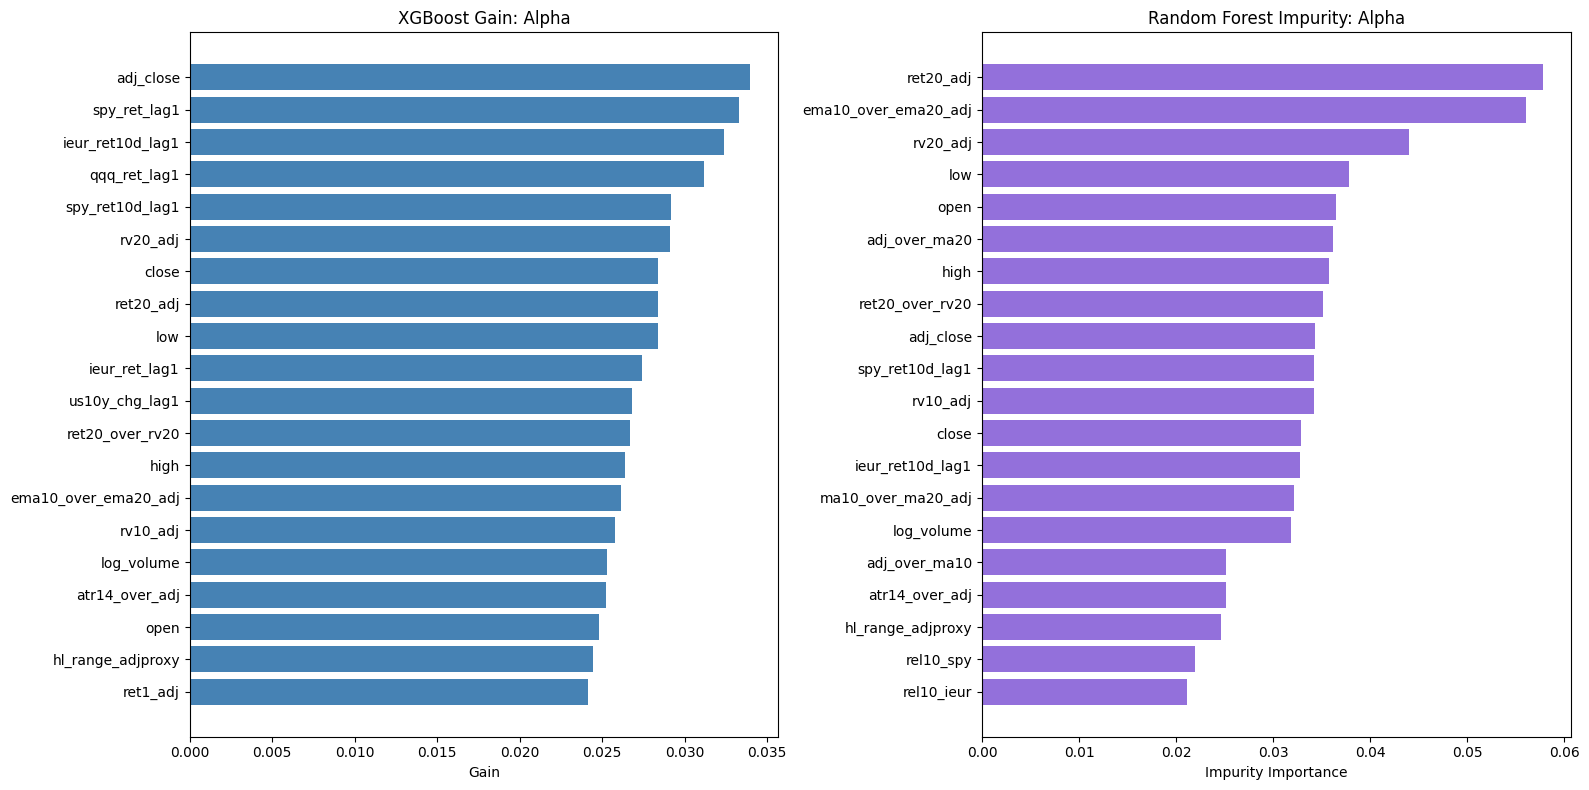

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_alpha = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf_alpha.fit(alpha_clean[alpha_xcols], alpha_clean["y_alpha"])

imp_rf_alpha = pd.Series(
    rf_alpha.feature_importances_, index=alpha_xcols, name="rf_impurity"
).sort_values(ascending=False)

print("=== Random Forest Impurity Importance: Alpha (top 20) ===")
print(imp_rf_alpha.head(20).to_string())

# --- Side-by-side comparison: XGBoost vs RandomForest for Alpha ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_xgb = imp_alpha.head(20)
axes[0].barh(top_xgb.index[::-1], top_xgb.values[::-1], color="steelblue")
axes[0].set_title("XGBoost Gain: Alpha")
axes[0].set_xlabel("Gain")

top_rf = imp_rf_alpha.head(20)
axes[1].barh(top_rf.index[::-1], top_rf.values[::-1], color="mediumpurple")
axes[1].set_title("Random Forest Impurity: Alpha")
axes[1].set_xlabel("Impurity Importance")

plt.tight_layout()
plt.show()

## 4. Cross-Method Comparison

Combine all three approaches into a single ranked table per target to see which features are consistently important across methods.

In [11]:
def build_comparison(gra_s, corr_df, xgb_s, label="target", rf_s=None):
    """Build a unified rank-comparison table across 3 or 4 methods.
    
    Each method's values are rank-ordered (1 = most important).
    avg_rank = mean of all ranks — lower is better.
    """
    data = {
        "GRG": gra_s,
        "abs_spearman": corr_df.set_index("feature")["abs_spearman"],
        "xgb_gain": xgb_s,
    }
    if rf_s is not None:
        data["rf_impurity"] = rf_s
    
    df = pd.DataFrame(data)
    rank_cols = []
    for col in df.columns:
        rc = f"rank_{col}"
        df[rc] = df[col].rank(ascending=False)
        rank_cols.append(rc)
    df["avg_rank"] = df[rank_cols].mean(axis=1)
    df = df.sort_values("avg_rank")
    return df

# Alpha (4 methods: GRA, Spearman, XGBoost, RandomForest)
comp_alpha = build_comparison(gra_alpha, corr_alpha, imp_alpha, "alpha", rf_s=imp_rf_alpha)
print("=== Cross-Method Ranking: Alpha (top 15 by avg rank) — 4 methods ===")
display_cols_4 = ["GRG", "abs_spearman", "xgb_gain", "rf_impurity",
                  "rank_GRG", "rank_abs_spearman", "rank_xgb_gain", "rank_rf_impurity", "avg_rank"]
print(comp_alpha[display_cols_4].head(15).round(4).to_string())

# Gate (3 methods)
comp_gate = build_comparison(gra_gate, corr_gate, imp_gate, "gate")
print(f"\n=== Cross-Method Ranking: Gate (top 15 by avg rank) ===")
display_cols_3 = ["GRG", "abs_spearman", "xgb_gain", "rank_GRG", "rank_abs_spearman", "rank_xgb_gain", "avg_rank"]
print(comp_gate[display_cols_3].head(15).round(4).to_string())

# Regime (3 methods)
comp_regime = build_comparison(gra_regime, corr_regime, imp_regime, "regime")
print(f"\n=== Cross-Method Ranking: Regime (all) ===")
print(comp_regime[display_cols_3].round(4).to_string())

=== Cross-Method Ranking: Alpha (top 15 by avg rank) — 4 methods ===
                       GRG  abs_spearman  xgb_gain  rf_impurity  rank_GRG  rank_abs_spearman  rank_xgb_gain  rank_rf_impurity  avg_rank
ret20_over_rv20     0.7487        0.0350    0.0267       0.0351      13.0                8.0           12.0               8.0     10.25
ret20_adj           0.6422        0.0344    0.0284       0.0578      29.0               10.0            8.0               1.0     12.00
adj_over_ma20       0.9197        0.0347    0.0195       0.0361       1.0                9.0           33.0               6.0     12.25
high                0.7801        0.0124    0.0264       0.0358       7.0               27.0           13.0               7.0     13.50
low                 0.7796        0.0119    0.0284       0.0378      10.0               31.0            9.0               4.0     13.50
adj_close           0.7709        0.0090    0.0340       0.0343      12.0               35.0            1.0        

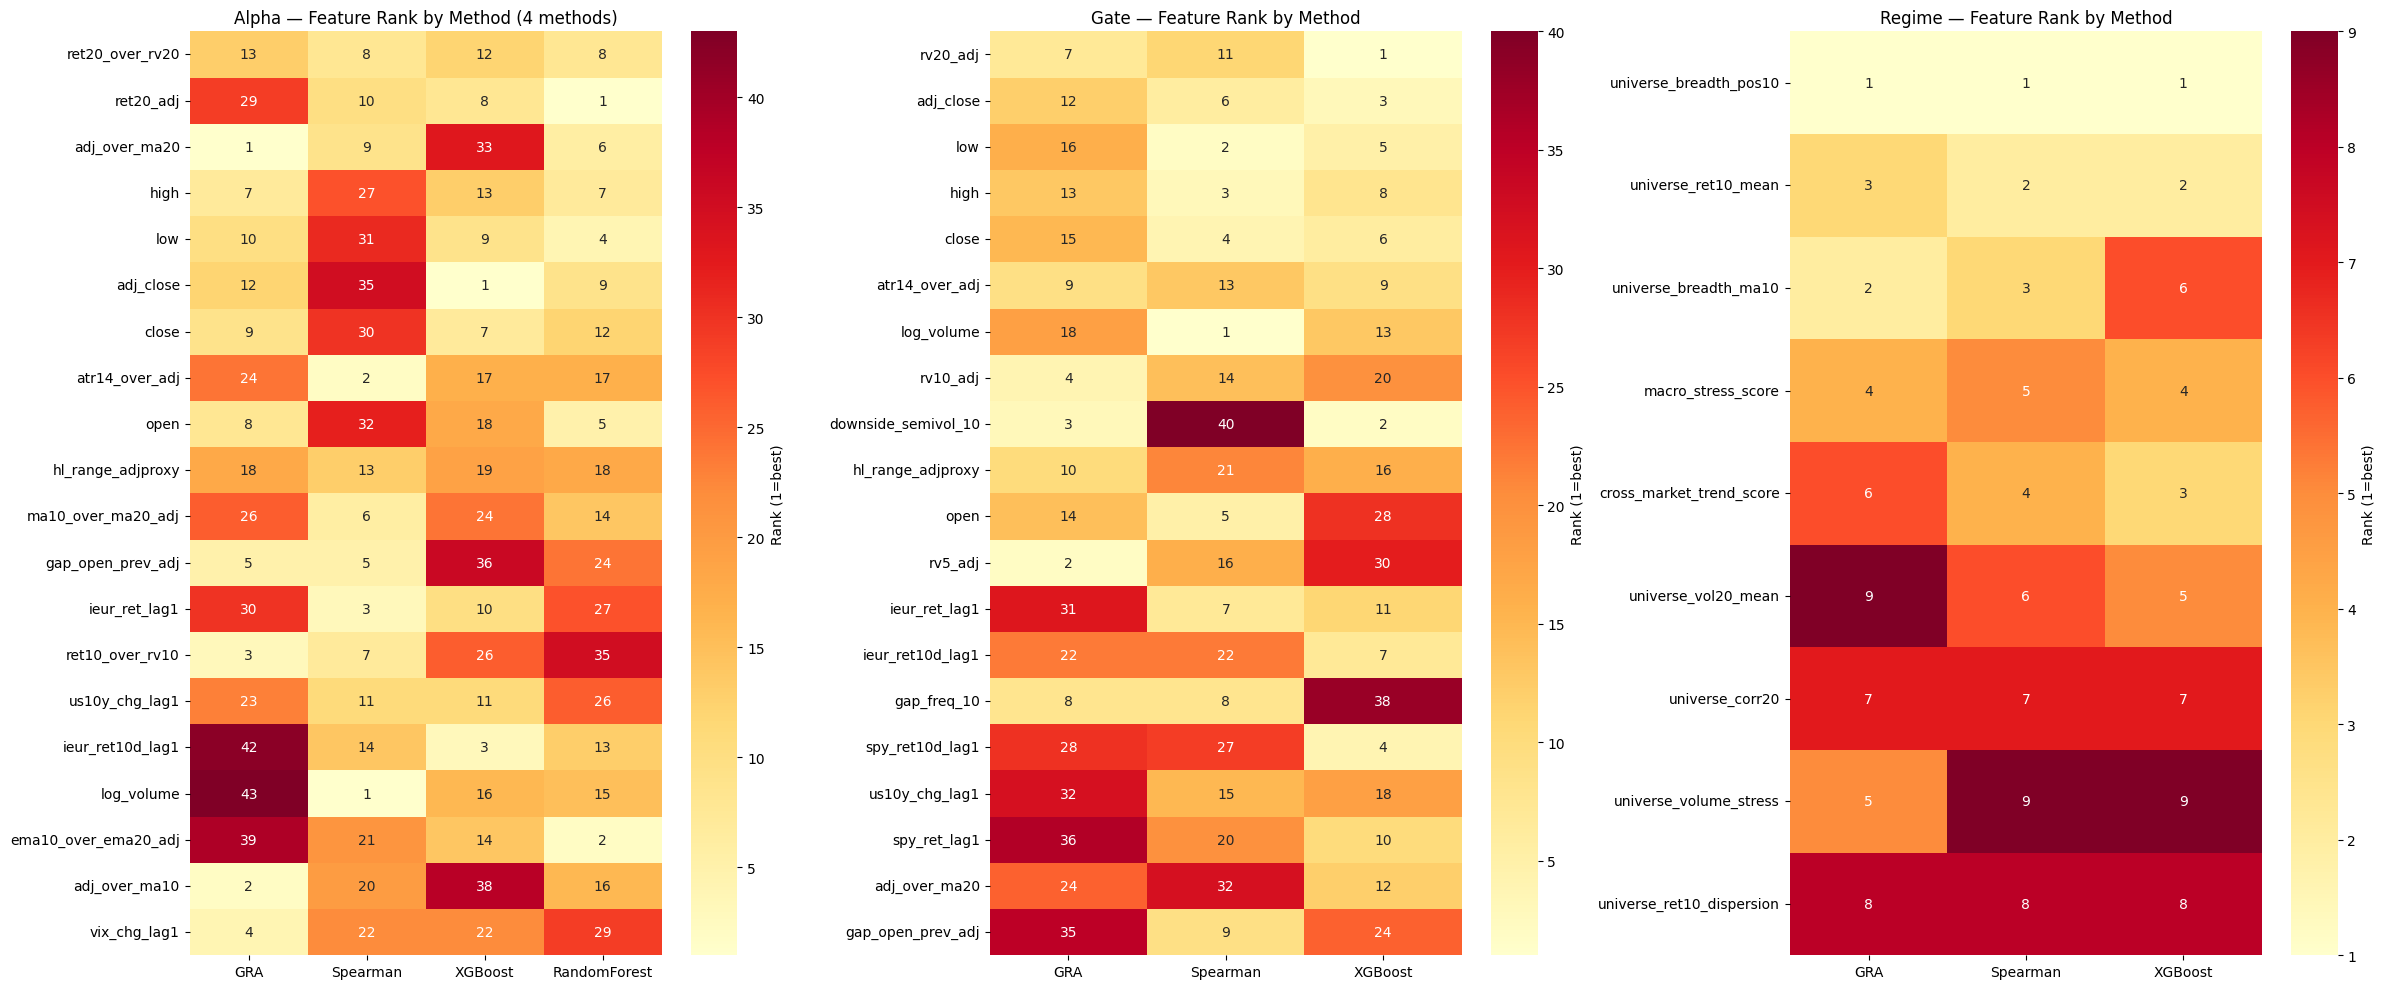

In [12]:
# --- Rank comparison heatmap ---
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Alpha: 4 methods
rank_cols_alpha = ["rank_GRG", "rank_abs_spearman", "rank_xgb_gain", "rank_rf_impurity"]
hm_alpha = comp_alpha.head(20)[rank_cols_alpha].copy()
hm_alpha.columns = ["GRA", "Spearman", "XGBoost", "RandomForest"]
sns.heatmap(hm_alpha, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"label": "Rank (1=best)"})
axes[0].set_title("Alpha — Feature Rank by Method (4 methods)")
axes[0].set_ylabel("")

# Gate: 3 methods
rank_cols_3 = ["rank_GRG", "rank_abs_spearman", "rank_xgb_gain"]
hm_gate = comp_gate.head(20)[rank_cols_3].copy()
hm_gate.columns = ["GRA", "Spearman", "XGBoost"]
sns.heatmap(hm_gate, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "Rank (1=best)"})
axes[1].set_title("Gate — Feature Rank by Method")
axes[1].set_ylabel("")

# Regime: 3 methods
hm_regime = comp_regime[rank_cols_3].copy()
hm_regime.columns = ["GRA", "Spearman", "XGBoost"]
sns.heatmap(hm_regime, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[2], cbar_kws={"label": "Rank (1=best)"})
axes[2].set_title("Regime — Feature Rank by Method")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Time-Split Feature Subset Experiments

Goal: test whether weak importance is mainly caused by feature redundancy/collinearity.
We evaluate **chronological** train/val/test performance for alpha and gate under three subsets:
1) full features (with OHLC levels), 2) no OHLC levels, 3) correlation-pruned (0.95).


In [13]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, log_loss
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

def chronological_split_by_date(df, date_col='date', train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    dates = np.array(sorted(df[date_col].unique()))
    n = len(dates)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    train_dates = dates[:n_train]
    val_dates = dates[n_train:n_train+n_val]
    test_dates = dates[n_train+n_val:n_train+n_val+n_test]
    tr = df[df[date_col].isin(train_dates)].copy()
    va = df[df[date_col].isin(val_dates)].copy()
    te = df[df[date_col].isin(test_dates)].copy()
    return tr, va, te

def corr_prune_columns(df, cols, threshold=0.95):
    if len(cols) <= 1:
        return list(cols), []
    corr = df[cols].corr().abs()
    keep = []
    drop = []
    for c in cols:
        if not keep:
            keep.append(c)
            continue
        if all(corr.loc[c, k] < threshold for k in keep):
            keep.append(c)
        else:
            drop.append(c)
    return keep, drop

price_level_cols = [c for c in ['open', 'high', 'low', 'close', 'adj_close'] if c in alpha_xcols]

alpha_full = list(alpha_xcols)
alpha_no_ohlc = [c for c in alpha_full if c not in price_level_cols]
alpha_pruned, alpha_dropped = corr_prune_columns(alpha_clean, alpha_full, threshold=0.95)

gate_full = list(gate_xcols)
gate_no_ohlc = [c for c in gate_full if c not in price_level_cols]
gate_pruned, gate_dropped = corr_prune_columns(gate_clean, gate_full, threshold=0.95)

print('Price-level columns:', price_level_cols)
print('Alpha subsets:', {'full': len(alpha_full), 'no_ohlc': len(alpha_no_ohlc), 'corr_pruned_095': len(alpha_pruned)})
print('Gate subsets: ', {'full': len(gate_full), 'no_ohlc': len(gate_no_ohlc), 'corr_pruned_095': len(gate_pruned)})
print('Alpha dropped by corr prune (sample):', alpha_dropped[:10])
print('Gate dropped by corr prune (sample): ', gate_dropped[:10])


Price-level columns: ['open', 'high', 'low', 'close', 'adj_close']
Alpha subsets: {'full': 43, 'no_ohlc': 38, 'corr_pruned_095': 38}
Gate subsets:  {'full': 48, 'no_ohlc': 43, 'corr_pruned_095': 43}
Alpha dropped by corr prune (sample): ['gap_open_prev_adj', 'high', 'low', 'close', 'adj_close']
Gate dropped by corr prune (sample):  ['gap_open_prev_adj', 'high', 'low', 'close', 'adj_close']


In [14]:
def run_alpha_experiment(df, feature_cols, exp_name):
    tr, va, te = chronological_split_by_date(df)
    X_tr, y_tr = tr[feature_cols].values, tr['y_alpha'].values
    X_va, y_va = va[feature_cols].values, va['y_alpha'].values
    X_te, y_te = te[feature_cols].values, te['y_alpha'].values

    model = XGBRegressor(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        importance_type='gain',
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    pred = model.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_te, pred)
    rho, _ = spearmanr(y_te, pred)

    perm = permutation_importance(
        model, X_te, y_te,
        n_repeats=5,
        random_state=42,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )
    perm_s = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

    return {
        'experiment': exp_name,
        'n_features': len(feature_cols),
        'rmse': rmse,
        'r2': float(r2),
        'spearman': float(rho),
        'top_perm': perm_s.head(10),
        'top_gain': pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10),
    }

def run_gate_experiment(df, feature_cols, exp_name):
    tr, va, te = chronological_split_by_date(df)
    y_map = {-1: 0, 0: 1, 1: 2}

    X_tr, y_tr = tr[feature_cols].values, tr['barrier_label'].map(y_map).values
    X_va, y_va = va[feature_cols].values, va['barrier_label'].map(y_map).values
    X_te, y_te = te[feature_cols].values, te['barrier_label'].map(y_map).values

    model = XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        num_class=3,
        importance_type='gain',
    )
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    prob = model.predict_proba(X_te)
    pred = prob.argmax(axis=1)

    acc = accuracy_score(y_te, pred)
    f1m = f1_score(y_te, pred, average='macro')
    ll = log_loss(y_te, prob)

    macro_f1_scorer = make_scorer(f1_score, average='macro')
    perm = permutation_importance(
        model, X_te, y_te,
        n_repeats=5,
        random_state=42,
        scoring=macro_f1_scorer,
        n_jobs=-1,
    )
    perm_s = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

    return {
        'experiment': exp_name,
        'n_features': len(feature_cols),
        'accuracy': float(acc),
        'f1_macro': float(f1m),
        'logloss': float(ll),
        'top_perm': perm_s.head(10),
        'top_gain': pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10),
    }

alpha_runs = [
    run_alpha_experiment(alpha_clean, alpha_full, 'alpha_full_ohlc'),
    run_alpha_experiment(alpha_clean, alpha_no_ohlc, 'alpha_no_ohlc'),
    run_alpha_experiment(alpha_clean, alpha_pruned, 'alpha_corr_pruned_095'),
]

gate_runs = [
    run_gate_experiment(gate_clean, gate_full, 'gate_full_ohlc'),
    run_gate_experiment(gate_clean, gate_no_ohlc, 'gate_no_ohlc'),
    run_gate_experiment(gate_clean, gate_pruned, 'gate_corr_pruned_095'),
]

alpha_summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ['top_perm', 'top_gain']} for r in alpha_runs]).sort_values('rmse')
gate_summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ['top_perm', 'top_gain']} for r in gate_runs]).sort_values('f1_macro', ascending=False)

print('=== Alpha experiment summary (lower RMSE better) ===')
print(alpha_summary.to_string(index=False))
print('\n=== Gate experiment summary (higher F1_macro better) ===')
print(gate_summary.to_string(index=False))

best_alpha = alpha_summary.iloc[0]['experiment']
best_gate = gate_summary.iloc[0]['experiment']

alpha_best_obj = [r for r in alpha_runs if r['experiment'] == best_alpha][0]
gate_best_obj = [r for r in gate_runs if r['experiment'] == best_gate][0]

print('\n=== Best Alpha top permutation importance ===')
print(alpha_best_obj['top_perm'].to_string())
print('\n=== Best Alpha top gain importance ===')
print(alpha_best_obj['top_gain'].to_string())

print('\n=== Best Gate top permutation importance ===')
print(gate_best_obj['top_perm'].to_string())
print('\n=== Best Gate top gain importance ===')
print(gate_best_obj['top_gain'].to_string())


=== Alpha experiment summary (lower RMSE better) ===
           experiment  n_features     rmse        r2  spearman
alpha_corr_pruned_095          38 0.067994 -0.160379  0.059700
        alpha_no_ohlc          38 0.068223 -0.168232  0.035806
      alpha_full_ohlc          43 0.068879 -0.190805  0.063809

=== Gate experiment summary (higher F1_macro better) ===
          experiment  n_features  accuracy  f1_macro  logloss
      gate_full_ohlc          48  0.475508  0.333755 0.924271
gate_corr_pruned_095          43  0.474584  0.333400 0.922628
        gate_no_ohlc          43  0.472043  0.328422 0.924720

=== Best Alpha top permutation importance ===
open                 0.000137
adj_over_ma10        0.000096
rv10_adj             0.000061
ret10_over_rv10      0.000060
rv5_adj              0.000046
ret3_adj             0.000045
spy_ret10d_lag1      0.000037
zscore10_adj         0.000027
adj_over_ma20        0.000027
hl_range_adjproxy    0.000024

=== Best Alpha top gain importance ===
rv